In [126]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

In [127]:
# ─────────────────────────────────────────────────────────────
# DATA  –  edit this section with your measurements
# ─────────────────────────────────────────────────────────────
# Each row: (H [A/m],  B [T],  sigma_B [T])
# Provide the ascending and descending branches separately.

df = pd.read_excel("datos_mazizo.xlsx")
B = df["B"].to_numpy()
H = df["H"].to_numpy()
errB = df["errB"].to_numpy()

data = np.column_stack([H, B, errB])

mid = len(H) // 2
ASCENDING  = (data[:mid])
DESCENDING = (data[mid:])

In [128]:
# ─────────────────────────────────────────────────────────────
# PARAMETERS
# ─────────────────────────────────────────────────────────────
N_TRIALS  = 10_000   # number of Monte Carlo samples
N_INTERP  = 500      # interpolation points on the H axis
SEED      = 42       # set to None for non-reproducible runs
SAVE_FIG  = True     # save figure to  hysteresis_mc_results.png

In [129]:
# ─────────────────────────────────────────────────────────────
# CORE FUNCTIONS
# ─────────────────────────────────────────────────────────────

def sort_branch(branch: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return H, B, sigma_B sorted by ascending H."""
    idx = np.argsort(branch[:, 0])
    return branch[idx, 0], branch[idx, 1], branch[idx, 2]


def loop_area(H_up, B_up, H_dn, B_dn, H_grid) -> float:
    """
    Numerically integrate the hysteresis loop area:
        W = ∮ H dB  ≈  Σ (B_up – B_dn) · ΔH
    over a common H_grid using linear interpolation.
    """
    B_up_i = np.interp(H_grid, H_up, B_up)
    B_dn_i = np.interp(H_grid, H_dn, B_dn)
    return float(np.abs(np.trapz(B_up_i - B_dn_i, H_grid)))


def monte_carlo(ascending, descending, n_trials, n_interp, rng):
    """
    Run Monte Carlo integration.

    For each trial, each B value is independently sampled from
        B_sample ~ N(B_measured, sigma_B^2)
    H values are treated as exact.

    Returns
    -------
    losses : ndarray of shape (n_trials,)
        Hysteresis loss [J/m³] for each trial.
    """
    H_up, B_up, sB_up = sort_branch(ascending)
    H_dn, B_dn, sB_dn = sort_branch(descending)

    H_min = min(H_up[0], H_dn[0])
    H_max = max(H_up[-1], H_dn[-1])
    H_grid = np.linspace(H_min, H_max, n_interp)

    # Sample all trials at once for speed: shape (n_trials, n_points)
    B_up_samples = B_up + rng.normal(0, sB_up, size=(n_trials, len(B_up)))
    B_dn_samples = B_dn + rng.normal(0, sB_dn, size=(n_trials, len(B_dn)))

    # Vectorised interpolation over all trials
    # np.interp is 1-D; use searchsorted for batched version
    def batch_interp(x_new, x_known, y_batch):
        """Interpolate each row of y_batch at x_new points."""
        idx = np.searchsorted(x_known, x_new, side='right') - 1
        idx = np.clip(idx, 0, len(x_known) - 2)
        x0, x1 = x_known[idx], x_known[idx + 1]
        t = (x_new - x0) / (x1 - x0)
        return y_batch[:, idx] * (1 - t) + y_batch[:, idx + 1] * t  # (n_trials, n_grid)

    B_up_i = batch_interp(H_grid, H_up, B_up_samples)   # (n_trials, n_grid)
    B_dn_i = batch_interp(H_grid, H_dn, B_dn_samples)

    dH = np.diff(H_grid)
    mid_diff = (B_up_i[:, :-1] - B_dn_i[:, :-1] + B_up_i[:, 1:] - B_dn_i[:, 1:]) / 2
    losses = np.abs(np.sum(mid_diff * dH, axis=1))
    return losses


def compute_statistics(losses):
    """Return a dict with key statistics."""
    mean  = losses.mean()
    std   = losses.std(ddof=1)
    ci_lo = np.percentile(losses, 2.5)
    ci_hi = np.percentile(losses, 97.5)
    return dict(mean=mean, std=std, rel_unc=std/mean*100,
                ci_lo=ci_lo, ci_hi=ci_hi,
                median=np.median(losses), n=len(losses))



In [130]:
# ─────────────────────────────────────────────────────────────
# PLOTTING
# ─────────────────────────────────────────────────────────────

def plot_results(losses, stats, ascending, descending, save=True):
    fig = plt.figure(figsize=(12, 5))
    gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

    # ── LEFT: B-H loop with uncertainty bands ──────────────────
    ax1 = fig.add_subplot(gs[0])
    H_up, B_up, sB_up = sort_branch(ascending)
    H_dn, B_dn, sB_dn = sort_branch(descending)

    ax1.fill_between(H_up, B_up - sB_up, B_up + sB_up,
                     alpha=0.20, color='#378add', label='σ_B band (asc)')
    ax1.fill_between(H_dn, B_dn - sB_dn, B_dn + sB_dn,
                     alpha=0.20, color='#D85A30', label='σ_B band (desc)')
    ax1.plot(H_up, B_up, 'o-', color='#378add', lw=1.8,
             ms=5, label='Ascending')
    ax1.plot(H_dn, B_dn, 's--', color='#D85A30', lw=1.8,
             ms=5, label='Descending')
    ax1.axhline(0, color='grey', lw=0.5, ls=':')
    ax1.axvline(0, color='grey', lw=0.5, ls=':')
    ax1.set_xlabel('H  (A/m)', fontsize=11)
    ax1.set_ylabel('B  (T)', fontsize=11)
    ax1.set_title('B-H loop with ±σ_B bands', fontsize=11)
    ax1.legend(fontsize=9, framealpha=0.5)
    ax1.grid(True, lw=0.4, alpha=0.4)

    # ── RIGHT: loss histogram ───────────────────────────────────
    ax2 = fig.add_subplot(gs[1])
    ci_lo, ci_hi = stats['ci_lo'], stats['ci_hi']
    n_bins = min(60, max(20, stats['n'] // 150))
    counts, edges, patches = ax2.hist(losses, bins=n_bins,
                                       color='#378add', alpha=0.75,
                                       edgecolor='none')
    # shade tails
    for patch, left in zip(patches, edges[:-1]):
        mid = left + (edges[1] - edges[0]) / 2
        if mid < ci_lo or mid > ci_hi:
            patch.set_facecolor('#aaaaaa')
            patch.set_alpha(0.5)

    ax2.axvline(stats['mean'],  color='#185FA5', lw=1.8,
                label=f"mean = {stats['mean']:.3f} J/m³")
    ax2.axvline(ci_lo, color='#D85A30', lw=1.2, ls='--',
                label=f"95% CI = [{ci_lo:.3f}, {ci_hi:.3f}]")
    ax2.axvline(ci_hi, color='#D85A30', lw=1.2, ls='--')

    ax2.set_xlabel('Hysteresis loss W  (J/m³)', fontsize=11)
    ax2.set_ylabel('Count', fontsize=11)
    ax2.set_title(f'MC loss distribution  (N = {stats["n"]:,})', fontsize=11)
    ax2.legend(fontsize=9, framealpha=0.5)
    ax2.grid(True, lw=0.4, alpha=0.4)

    fig.suptitle('Monte Carlo Hysteresis Loss Integrator', fontsize=13,
                 fontweight='normal', y=1.01)
    plt.tight_layout()

    if save:
        fname = 'hysteresis_mc_results.png'
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"\nFigure saved → {fname}")
    plt.show()


Running Monte Carlo integration …

──────────────────────────────────────────────
  HYSTERESIS LOSS — MONTE CARLO RESULTS
──────────────────────────────────────────────
  Trials (N)          :       10,000
  Mean  W             :       1.5164  mJ/cm³
  Std dev  σ_W        :       0.0072  mJ/cm³
  Relative uncertainty:       0.476 %
  Median              :       1.5164  mJ/cm³
  95% CI (low)        :       1.5025  mJ/cm³
  95% CI (high)       :       1.5305  mJ/cm³
──────────────────────────────────────────────

  Result:  W = 1.5164 ± 0.0072 mJ/cm³
           (95% CI: [1.5025, 1.5305] mJ/cm³)



C:\Users\Alex\AppData\Local\Temp\ipykernel_6276\1361549966.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



Figure saved → hysteresis_mc_results.png


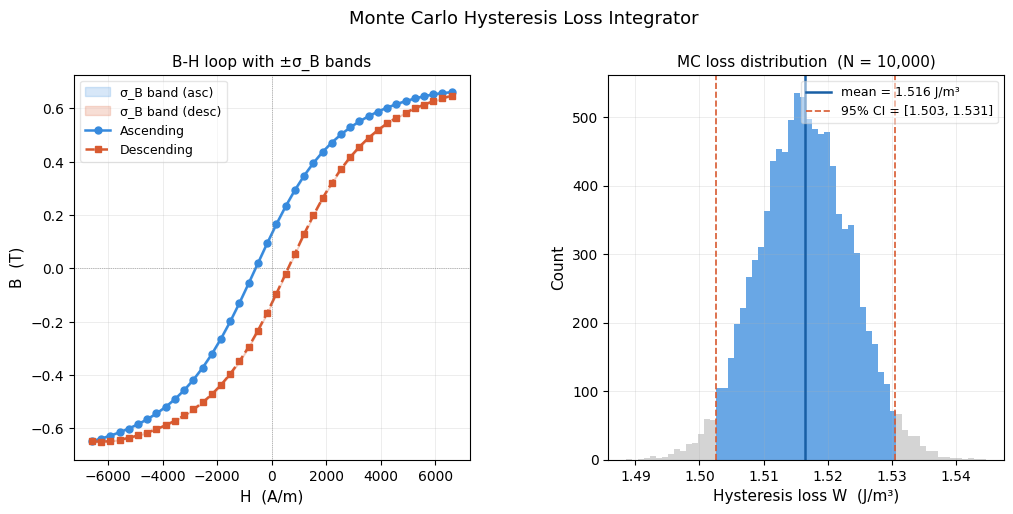

In [131]:
# ─────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────


rng = np.random.default_rng(SEED)

print("Running Monte Carlo integration …")
losses = monte_carlo(ASCENDING, DESCENDING, N_TRIALS, N_INTERP, rng) / 1000
stats  = compute_statistics(losses)

# ── Print results ─────────────────────────────────────────
sep = "─" * 46
print(f"\n{sep}")
print("  HYSTERESIS LOSS — MONTE CARLO RESULTS")
print(sep)
print(f"  Trials (N)          : {stats['n']:>12,}")
print(f"  Mean  W             : {stats['mean']:>12.4f}  mJ/cm³")
print(f"  Std dev  σ_W        : {stats['std']:>12.4f}  mJ/cm³")
print(f"  Relative uncertainty: {stats['rel_unc']:>11.3f} %")
print(f"  Median              : {stats['median']:>12.4f}  mJ/cm³")
print(f"  95% CI (low)        : {stats['ci_lo']:>12.4f}  mJ/cm³")
print(f"  95% CI (high)       : {stats['ci_hi']:>12.4f}  mJ/cm³")
print(sep)
print(f"\n  Result:  W = {stats['mean']:.4f} ± {stats['std']:.4f} mJ/cm³")
print(f"           (95% CI: [{stats['ci_lo']:.4f}, {stats['ci_hi']:.4f}] mJ/cm³)")
print()

plot_results(losses, stats, ASCENDING, DESCENDING, save=SAVE_FIG)